In [ ]:
%load_ext autoreload
%autoreload 2

In [28]:
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
import mesa

from model import SocialGPModel
from rewards import (
    sample_children_with_corr,
    make_parent_and_children_cholesky2,
    build_corr_matrix_option1,
    build_corr_matrix_option2,
    build_corr_matrix_option3,
    _min_max,
)
from tqdm import tqdm

In [29]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [30]:
rho_variants_raw = {
    "perfectly_calibrated":  np.array([1.0,  0.6,  0.0,  -0.6]), # beliefs match the true environment
    "sign_flipped":          np.array([1.0, -0.6,  0.0,  0.6]),  # trusts the anti-correlated peer and avoids the helpful one
    "socially_agnostic":     np.array([1.0,  0.0,  0.0,  0.0]),  # ignores all social information
    "uniform_over_trusting": np.array([1.0,  0.6,  0.6,  0.6]),  # assumes everyone is positively aligned (over-generalization)
    "uniform_distrusting":   np.array([1.0, -0.6, -0.6,  -0.6]), # assumes everyone is anti-correlated (over-avoidance)
    "overconfident":         np.array([1.0,  0.9,  0.0,  -0.9]), # right signs, inflated strength; tests sensitivity to overconfidence
    "underconfident":        np.array([1.0,  0.2,  0.0,  -0.2]), # right signs, damped strength; tests robustness to weak beliefs
    "selective_trust":       np.array([1.0,  0.6,  0.0,  0.0]),  # trusts only the truly helpful peer; ignores the harmful one
    "selective_avoidance":   np.array([1.0,  0.0,  0.0,  -0.6]), # avoids only the harmful peer; ignores the helpful one
}

def project_rho_to_pd(rho_vec, max_norm=0.99):
    """Ensure the hub-correlation matrix stays PD by capping ‖rho_social‖₂."""
    rho_vec = np.asarray(rho_vec, dtype=float)
    social = rho_vec[1:]
    norm = np.linalg.norm(social)
    if norm >= max_norm and norm > 0:
        rho_vec[1:] = social * (max_norm / norm)
    return rho_vec

rho_variants = {name: project_rho_to_pd(v) for name, v in rho_variants_raw.items()}
rho_list = list(rho_variants.values())
rho_label_lookup = {tuple(v.round(6)): name for name, v in rho_variants.items()}

def label_rho(rho_arr):
    """Map a rho array to its scenario name; returns 'unknown' if not in the table."""
    key = tuple(np.asarray(rho_arr).round(6))  # tolerate float repr differences
    return rho_label_lookup.get(key, "unknown")

## Plot correlations

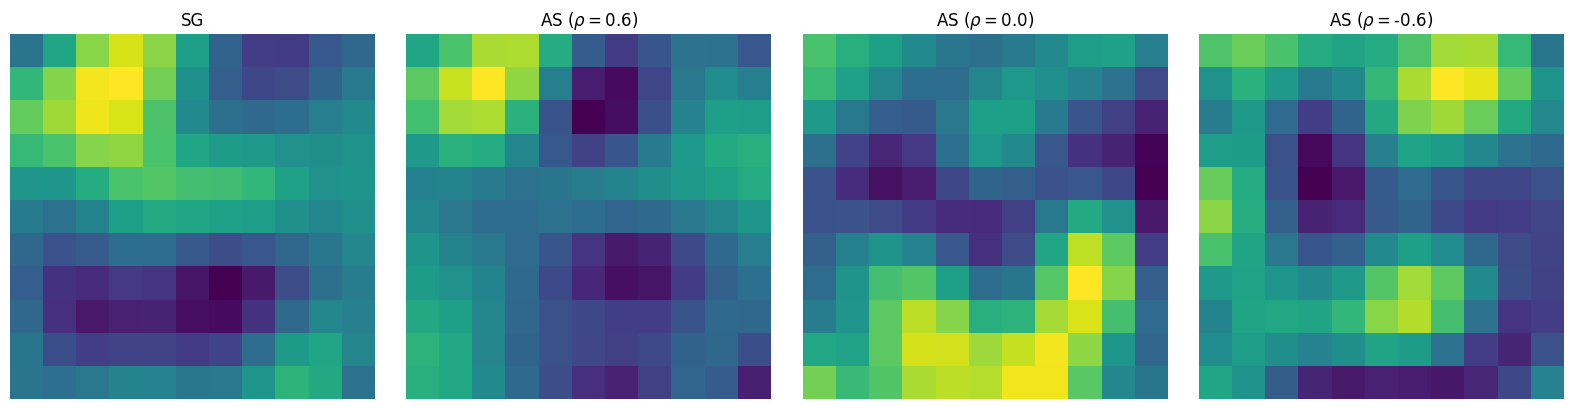

In [31]:
corr_matrix = build_corr_matrix_option1()  # parent + 3 children
n_children = corr_matrix.shape[0] - 1

seed = 0
a_rng = np.random.default_rng(seed)

grid_size = 11 # change resolution
parent, child_maps = make_parent_and_children_cholesky2(
    rng=a_rng,
    grid_size=grid_size,
    n_children=n_children + 1,
    length_scale=2.0,
    corr_matrix=corr_matrix,
)

# keep reward scale consistent with other sims
child_maps = [_min_max(c) - 0.5 for c in child_maps]

fig, axes = plt.subplots(1, len(child_maps) + 1, figsize=(4 * (len(child_maps) + 1), 4))

# parent
axes[0].imshow(_min_max(parent) - 0.5, origin='lower')
axes[0].set_title("SG")
axes[0].axis('off')

# children
for _corr, c, ax in zip([0.6, 0.0, -0.6], child_maps, axes[1:]):
    ax.imshow(c, origin='lower')
    ax.set_title(fr"AS ($\rho=${_corr})")
    ax.axis('off')

plt.tight_layout()
plt.show()

## Run the model

In [32]:
m = SocialGPModel(
    n=n_children + 1,
    model_type="SG-ICM",
    child_maps=[parent] + child_maps,
    network_type="directed_one_to_four",
    rho=np.array([1.0, 0.6, 0.0, -0.6]),
    tau_sampling=True,  # tau=0.03
    beta_sampling=True,
    length_scale_sampling=True,
)

for _ in range(15):
    m.step()

results = m.datacollector.get_agent_vars_dataframe()

results.head(20)

choice    reward  cumulative_reward model_type      tau
Step AgentID                                                          
1    1         (7, 2)  1.866117           1.866117     SG-ICM  0.00871
     2         (8, 5) -0.502294          -0.502294         AS  0.00871
     3         (9, 6)  0.051174           0.051174         AS  0.00871
     4        (10, 2)  0.227074           0.227074         AS  0.00871
2    1         (7, 2)  1.866492           3.232609     SG-ICM  0.00871
     2         (0, 3) -0.161439          -1.163733         AS  0.00871
     3         (5, 2) -0.288283          -0.737108         AS  0.00871
     4         (5, 1)  0.104330          -0.168596         AS  0.00871
3    1         (7, 2)  1.843447           4.576055     SG-ICM  0.00871
     2         (1, 9) -0.170810          -1.834543         AS  0.00871
     3         (0, 0)  0.289143          -0.947965         AS  0.00871
     4         (9, 8)  0.460253          -0.208343         AS  0.00871
4    1         (7, 2)  1.858905           5.934960     SG-ICM  0.00871
     2         (7, 1)  0.145662          -2.188881         AS  0.00871
     3         (0, 4)  0.398355          -1.049610         AS  0.00871
     4        (10, 5)  0.097897          -0.610447         AS  0.00871
5    1         (7, 2)  1.856298           7.291258     SG-ICM  0.00871
     2         (4, 0)  0.029283          -2.659599         AS  0.00871
     3        (7, 10) -0.493400          -2.043010         AS  0.00871
     4        (2, 10) -0.320496          -1.430943         AS  0.00871

In [33]:
R = build_corr_matrix_option1()

param_grid = {
    "n": 4,
    "model_type": "SG-ICM",
    "observation_noise_private": 0.0001,
    "observation_noise_social":  0.0001,
    "tau_sampling": True,
    "beta_sampling": True,
    "length_scale_sampling": True,
    "length_scale_is_identical": True,
    "seed": list(range(1000)),
    "network_type": "directed_one_to_four",
    "rho": rho_list,
    "corr_matrix": [R]
}

batch_results = mesa.batch_run(
    SocialGPModel,
    parameters=param_grid,
    iterations=1,
    max_steps=15,
    number_processes=None,
    data_collection_period=1,
    display_progress=True,
)

batch_results = pd.DataFrame(batch_results)

  0%|          | 0/9000 [00:00<?, ?it/s]

In [34]:
batch_results = pd.DataFrame(batch_results)
batch_results['rho_label'] = batch_results['rho'].apply(label_rho)
batch_results.head()


,RunId,iteration,Step,n,model_type,observation_noise_private,observation_noise_social,tau_sampling,beta_sampling,length_scale_sampling,length_scale_is_identical,seed,network_type,rho,corr_matrix,avg_cumulative_reward,avg_reward,AgentID,choice,reward,cumulative_reward,tau,rho_label
0,1,0,0,4,SG-ICM,0.0001,0.0001,True,True,True,True,0,directed_one_to_four,"[1.0, -0.6, 0.0, 0.6]","[[1.0, 0.6, 0.0, -0.6], [0.6, 1.0, 0.0, 0.0], ...",0.443456,0.443456,NaN,NaN,NaN,NaN,NaN,sign_flipped
1,1,0,1,4,SG-ICM,0.0001,0.0001,True,True,True,True,0,directed_one_to_four,"[1.0, -0.6, 0.0, 0.6]","[[1.0, 0.6, 0.0, -0.6], [0.6, 1.0, 0.0, 0.0], ...",0.701827,0.350914,1.0,"(9, 9)",0.654450,0.654450,0.01244,sign_flipped
2,1,0,1,4,AS,0.0001,0.0001,True,True,True,True,0,directed_one_to_four,"[1.0, -0.6, 0.0, 0.6]","[[1.0, 0.6, 0.0, -0.6], [0.6, 1.0, 0.0, 0.0], ...",0.701827,0.350914,2.0,"(5, 4)",0.561097,0.561097,0.01244,sign_flipped
3,1,0,1,4,AS,0.0001,0.0001,True,True,True,True,0,directed_one_to_four,"[1.0, -0.6, 0.0, 0.6]","[[1.0, 0.6, 0.0, -0.6], [0.6, 1.0, 0.0, 0.0], ...",0.701827,0.350914,3.0,"(9, 8)",0.327141,0.327141,0.01244,sign_flipped
4,1,0,1,4,AS,0.0001,0.0001,True,True,True,True,0,directed_one_to_four,"[1.0, -0.6, 0.0, 0.6]","[[1.0, 0.6, 0.0, -0.6], [0.6, 1.0, 0.0, 0.0], ...",0.701827,0.350914,4.0,"(3, 10)",0.231135,0.231135,0.01244,sign_flipped


In [35]:
def plot_reward(df, y_col="reward", keep_labels=None, figsize=(9, 5)):
    plot_df = df[df.model_type == "SG-ICM"].copy()
    if keep_labels:
        plot_df = plot_df[plot_df["rho_label"].isin(keep_labels)]
        hue_order = keep_labels
    else:
        hue_order = sorted(plot_df["rho_label"].unique())

    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=plot_df,
        x="Step",
        y=y_col,
        hue="rho_label",
        hue_order=hue_order,
        ax=ax,
    )
    ax.set_title(f"{y_col.replace('_', ' ').title()} under assumed task correlations")
    ax.set_xlabel("Step")
    ax.set_ylabel(y_col.replace("_", " ").title())
    ax.legend(
        title="Assumed correlation structure",
        bbox_to_anchor=(1.02, 0.5), loc="center left",
        borderaxespad=0,
    )
    plt.tight_layout()
    plt.show()

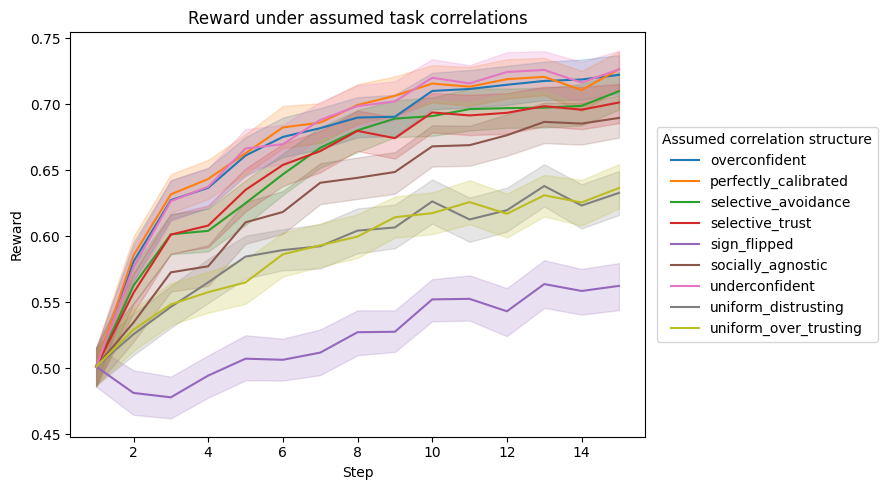

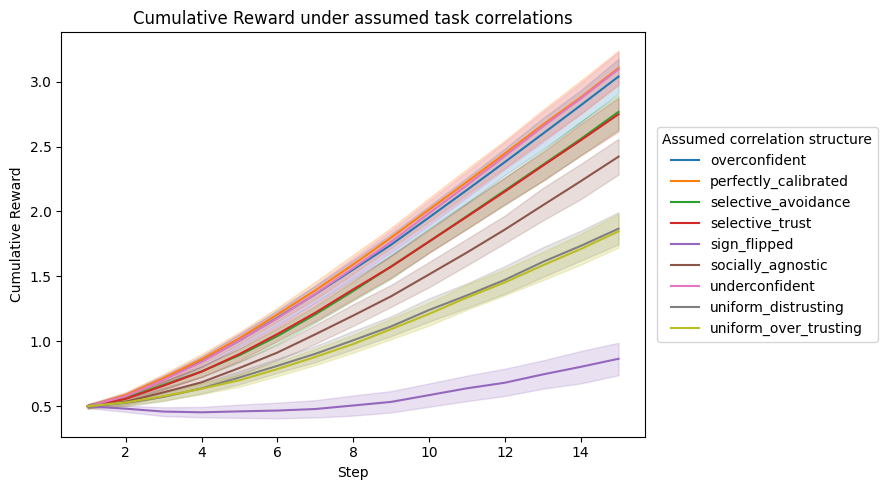

In [36]:
# All lines:
plot_reward(batch_results, y_col="reward")
plot_reward(batch_results, y_col="cumulative_reward")

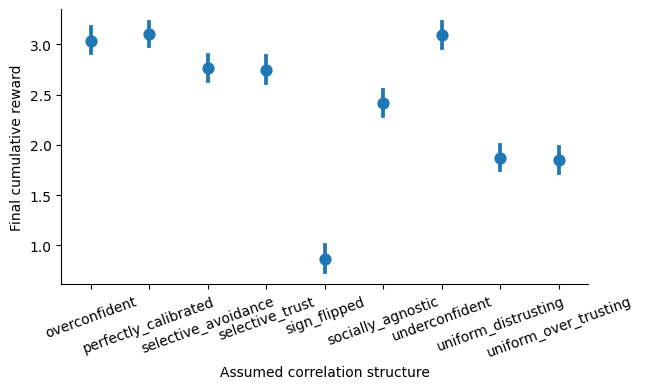

In [37]:
def plot_final_cumreward_catplot(df, x='rho_label'):
    plot_df = df[df.model_type == "SG-ICM"].copy()
    final_step = plot_df.groupby(['RunId', 'iteration'])['Step'].transform('max')
    last = plot_df[plot_df['Step'] == final_step].copy()

    sns.catplot(
        data=last,
        kind='point', # 'box',
        x=x,
        y='cumulative_reward',
        order=sorted(last[x].unique()),
        height=4,
        aspect=1.6,
        linestyle='none'
    )
    plt.xticks(rotation=20)
    plt.xlabel('Assumed correlation structure')
    plt.ylabel('Final cumulative reward')
    plt.tight_layout()
    plt.show()

plot_final_cumreward_catplot(batch_results)


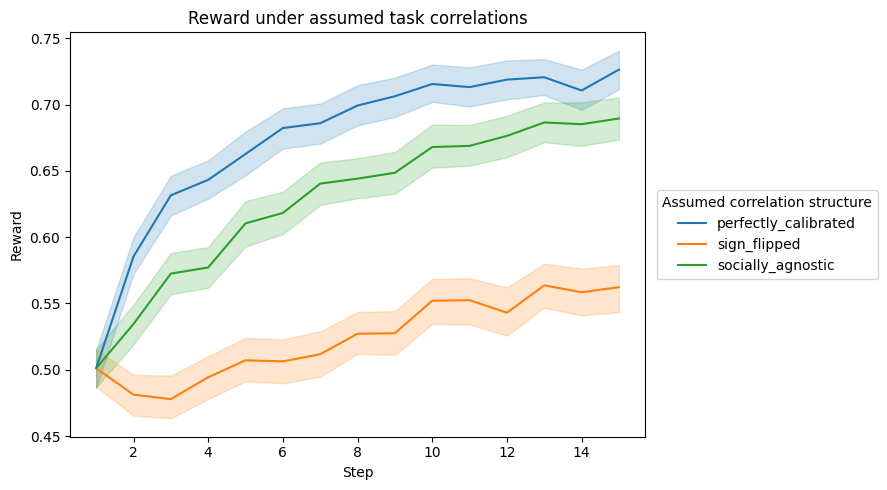

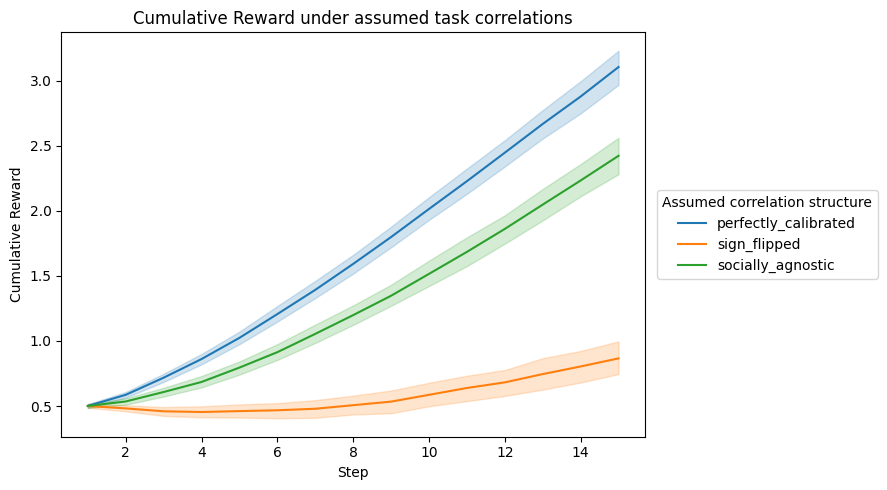

In [38]:
# Custom subset: 
my_subset = [
    "perfectly_calibrated",  # beliefs match the true environment
    "sign_flipped",          # trusts the anti-correlated peer and avoids the helpful one
    "socially_agnostic",     # ignores all social information
    ]
plot_reward(batch_results, y_col="reward", keep_labels=my_subset)
plot_reward(batch_results, y_col="cumulative_reward", keep_labels=my_subset)

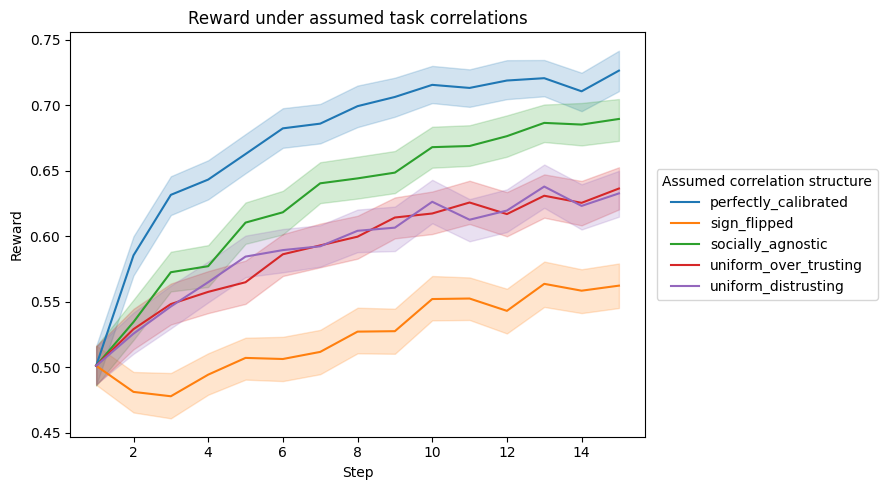

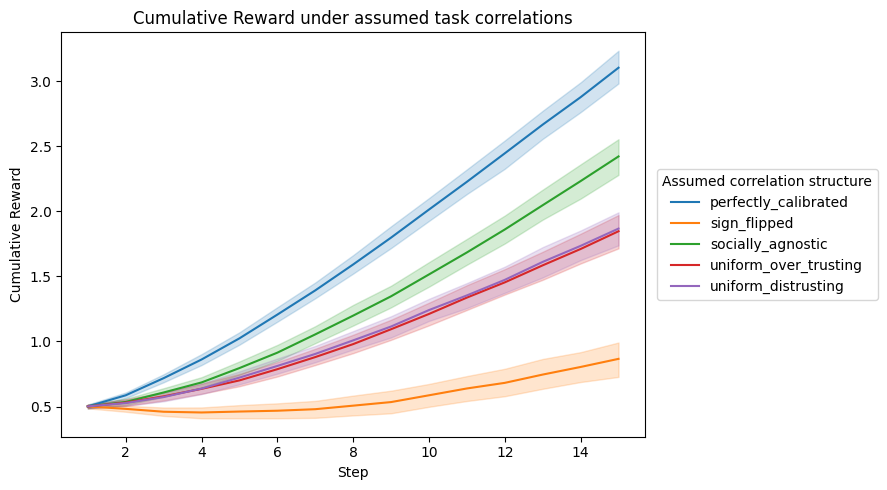

In [39]:
# Custom subset:
my_subset = [
    "perfectly_calibrated",  # beliefs match the true environment
    "sign_flipped",          # trusts the anti-correlated peer and avoids the helpful one
    "socially_agnostic",     # ignores all social information
    "uniform_over_trusting", # assumes everyone is positively aligned (over-generalization) 
    "uniform_distrusting"    # assumes everyone is anti-correlated (over-avoidance)
    ]
plot_reward(batch_results, y_col="reward", keep_labels=my_subset)
plot_reward(batch_results, y_col="cumulative_reward", keep_labels=my_subset)

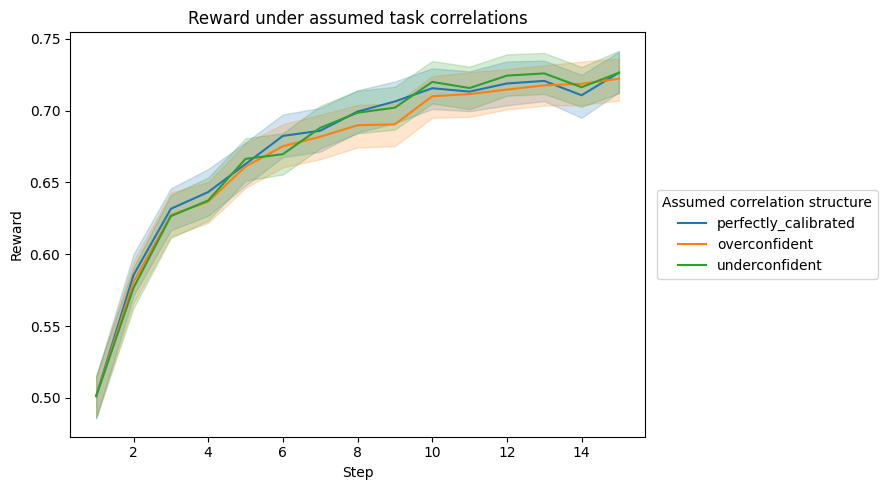

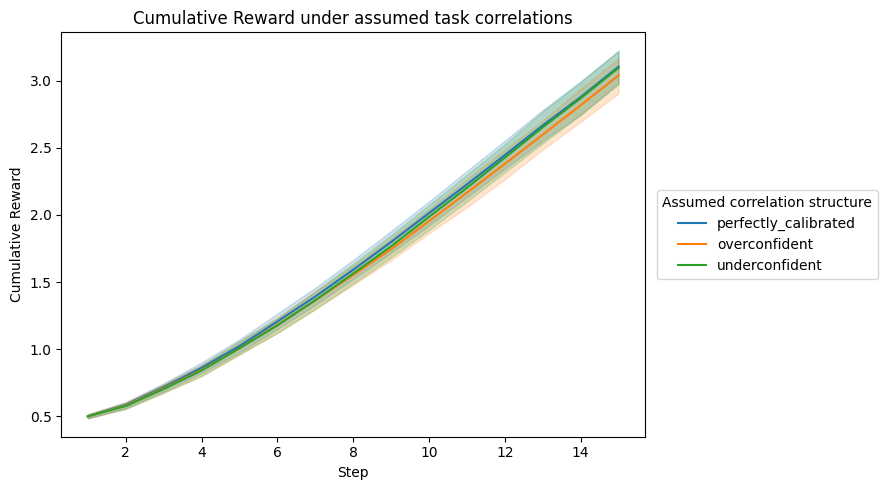

In [40]:
# Custom subset: knows who to trust or distrust, but the magnitude is not corect
my_subset = [
    "perfectly_calibrated",  # beliefs match the true environment
    "overconfident",          # right signs, inflated strength; tests sensitivity to overconfidence
    "underconfident",         # right signs, damped strength; tests robustness to weak beliefs
    ]
plot_reward(batch_results, y_col="reward", keep_labels=my_subset)
plot_reward(batch_results, y_col="cumulative_reward", keep_labels=my_subset)

# “aligned vs sign-flipped vs agnostic” to highlight correctness of belief.

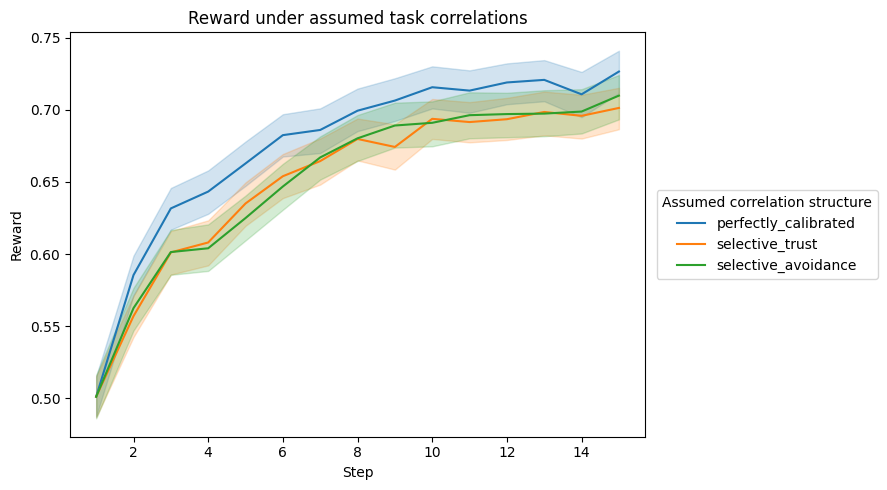

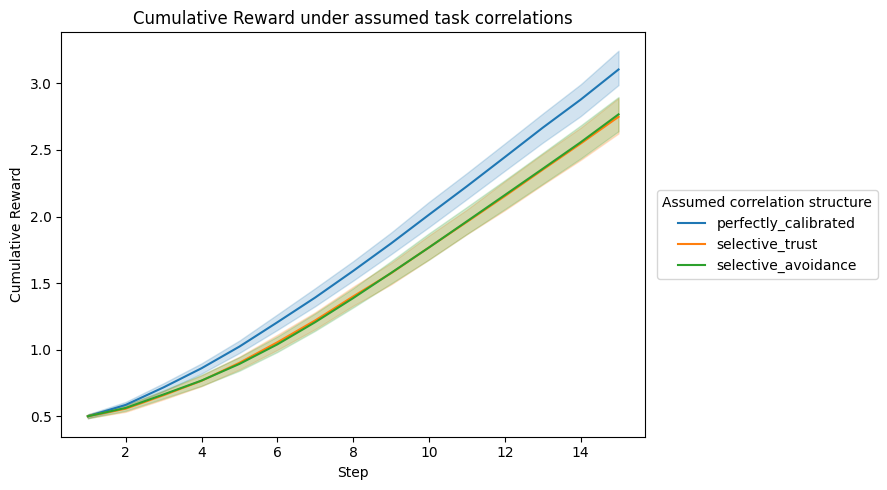

In [41]:
# Custom subset: [trust/distrust] the correct person, and ignore the one that should be [distrust/trust]
my_subset = [
    "perfectly_calibrated",  # beliefs match the true environment
    "selective_trust",        # trusts only the truly helpful peer; ignores the harmful one
    "selective_avoidance"    # avoids only the harmful peer; ignores the helpful one
    ]
plot_reward(batch_results, y_col="reward", keep_labels=my_subset)
plot_reward(batch_results, y_col="cumulative_reward", keep_labels=my_subset)

# “aligned vs sign-flipped vs agnostic” to highlight correctness of belief.